In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
data = pd.read_csv("../data/CincinnatiPaintCompany.csv")
data.head()

,Commissions,Calls,Driven
0,22,139,2371
1,13,132,2226
2,33,144,2731
3,38,142,3351
4,23,142,2289


In [10]:
dataX = data[["Calls","Driven"]]

XY_train = np.array(dataX)
z_train = data["Commissions"].values

In [12]:
regr2 = linear_model.LinearRegression()
regr2.fit(XY_train, z_train)
z_pred = regr2.predict(XY_train)
print('Coefficients: \n', regr2.coef_)
print("Mean squared error: %.2f" % mean_squared_error(z_train, z_pred))
print('Variance score: %.2f' % r2_score(z_train, z_pred))

Coefficients: 
 [0.63233256 0.01568925]
Mean squared error: 16.31
Variance score: 0.84


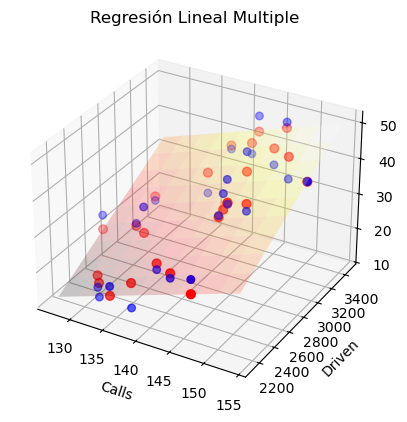

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

xx, yy = np.meshgrid(
    np.linspace(data["Calls"].min(), data["Calls"].max(), 10),
    np.linspace(data["Driven"].min(), data["Driven"].max(), 10)
)
nuevoX = (regr2.coef_[0] * xx)
nuevoY = (regr2.coef_[1] * yy)
z = (nuevoX + nuevoY + regr2.intercept_)
ax.plot_surface(xx, yy, z, alpha=0.2, cmap='hot')
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_train, c='blue',s=30)
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_pred, c='red',s=40)

ax.set_xlabel('Calls')
ax.set_ylabel('Driven')
ax.set_zlabel('Commissions')
ax.set_title('Regresión Lineal Multiple')
plt.show()

1.  Interpretación de la gráfica de correlación: 
    La gráfica muestra una relación positiva entre las comisiones, las llamadas y las millas recorridas, ya que al aumentar estas variables también aumentan las comisiones. El modelo explica aproximadamente el 84% de la variación, lo que indica una relación fuerte.

2. Comprobación con la fórmula de correlación: 
    Al calcular la correlación se obtienen coeficientes positivos altos entre las variables. Esto confirma que el análisis visual de la gráfica es correcto.